In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('./income.csv')

In [6]:
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [7]:
from matplotlib import pyplot as plt

Text(0, 0.5, 'Income ($)')

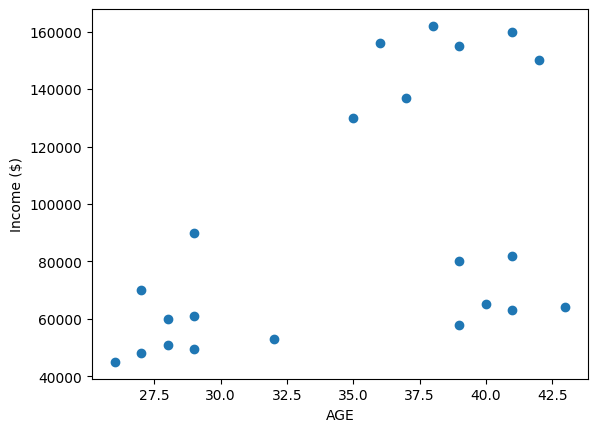

In [8]:
plt.scatter(df['Age'], df['Income($)'])
plt.xlabel('AGE')
plt.ylabel('Income ($)')

In [9]:
from sklearn.cluster import KMeans

In [10]:
km = KMeans()

In [30]:
km2 = KMeans(n_clusters=3)

In [31]:
y_pred_km = km.fit_predict(df[['Age', 'Income($)']])
y_pred_km

array([1, 4, 5, 5, 2, 2, 7, 7, 2, 0, 0, 3, 3, 3, 3, 3, 1, 1, 1, 6, 6, 5],
      dtype=int32)

In [32]:
y_pred_km2 = km2.fit_predict(df[['Age', 'Income($)']])
y_pred_km2

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [33]:
# df['cluster1'] = y_pred_km
df['cluster2'] = y_pred_km2
df

,Name,Age,Income($),cluster2
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,1


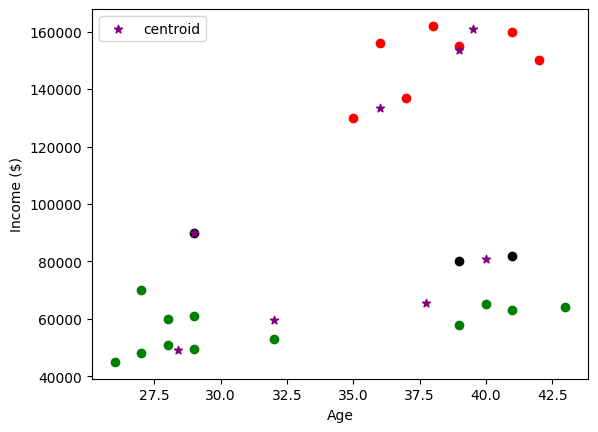

In [34]:
# Seperate dataframes for all three clusters. 
df1 = df[df.cluster2==0]
df2 = df[df.cluster2==1]
df3 = df[df.cluster2==2]

plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()

The above problem is because of unscaled data. 

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler = MinMaxScaler()

scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

In [14]:
df.head()

,Name,Age,Income($)
0,Rob,0.058824,0.213675
1,Michael,0.176471,0.384615
2,Mohan,0.176471,0.136752
3,Ismail,0.117647,0.128205
4,Kory,0.941176,0.897436


Now data is scaled between 0-1. Now lets see the results.

In [15]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Income($)']])
y_predicted

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [16]:
df['cluster'] = y_predicted

In [17]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


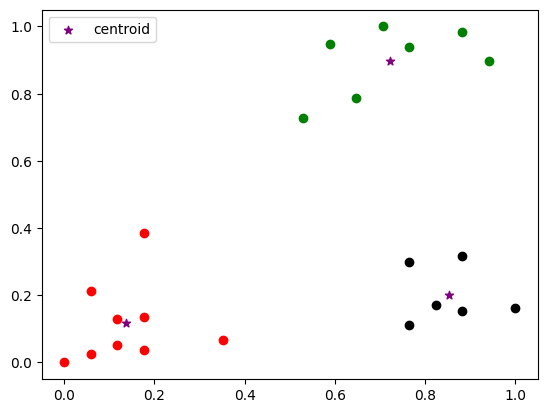

In [18]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

Good results.

# Now Elbow method. 

In [19]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)

In [20]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.38815291664787444,
 0.32657706599188696,
 0.2302234881568274,
 0.18281784627753636,
 0.14090581089405507,
 0.1321471082406226]

### We can see the error is decreasing with no of clusters increasing.

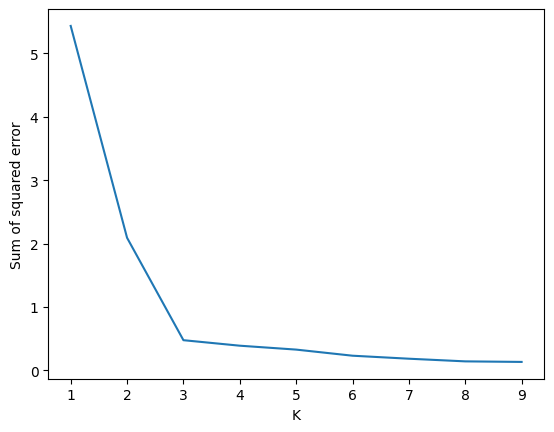

In [21]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

### Elbow is forming at k=3